
## Project 2: Data Classification Using AI



## Step 0 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

print("✅ All libraries imported successfully!")
print(f"   numpy      : {np.__version__}")
print(f"   pandas     : {pd.__version__}")
print(f"   sklearn    : imported")


✅ All libraries imported successfully!
   numpy      : 2.0.2
   pandas     : 2.2.2
   sklearn    : imported


## Step 1 — Load & Understand the Dataset

The **Iris Benchmark** is the classic supervised learning dataset:
- **150 samples** — perfectly balanced, 50 per class
- **3 classes** — Setosa, Versicolor, Virginica
- **4 features** — Sepal Length, Sepal Width, Petal Length, Petal Width


In [2]:
# Load the Iris dataset
iris = load_iris()

# Build a readable DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({
    0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'
})

print(f"Dataset Shape   : {df.shape[0]} samples × {len(iris.feature_names)} features")
print(f"Classes         : {iris.target_names.tolist()}")
print(f"Samples/Class   : {dict(df['species_name'].value_counts())}")
print()
df.head(10)


Dataset Shape   : 150 samples × 4 features
Classes         : ['setosa', 'versicolor', 'virginica']
Samples/Class   : {'Setosa': np.int64(50), 'Versicolor': np.int64(50), 'Virginica': np.int64(50)}



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
5,5.4,3.9,1.7,0.4,0,Setosa
6,4.6,3.4,1.4,0.3,0,Setosa
7,5.0,3.4,1.5,0.2,0,Setosa
8,4.4,2.9,1.4,0.2,0,Setosa
9,4.9,3.1,1.5,0.1,0,Setosa


In [3]:
# Statistical Summary
print("📊 Statistical Summary of Features:")
df[iris.feature_names].describe().round(2)


📊 Statistical Summary of Features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## Step 1b — Exploratory Data Analysis (EDA)

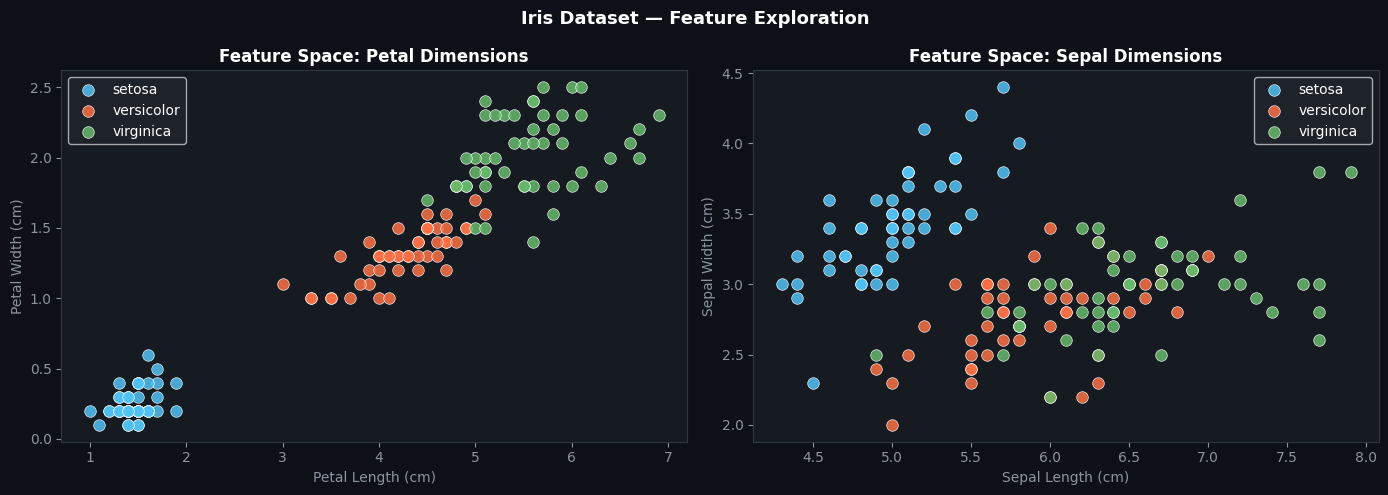

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')
colors = ['#4FC3F7', '#FF7043', '#66BB6A']
class_names = iris.target_names

# Petal feature space
ax = axes[0]
ax.set_facecolor('#161b22')
for i, (name, color) in enumerate(zip(class_names, colors)):
    mask = iris.target == i
    ax.scatter(iris.data[mask, 2], iris.data[mask, 3],
               c=color, label=name, s=70, alpha=0.85,
               edgecolors='white', linewidths=0.5)
ax.set_xlabel('Petal Length (cm)', color='#8b949e')
ax.set_ylabel('Petal Width (cm)',  color='#8b949e')
ax.set_title('Feature Space: Petal Dimensions', color='white', fontweight='bold')
ax.legend(facecolor='#21262d', labelcolor='white')
ax.tick_params(colors='#8b949e')
for sp in ax.spines.values(): sp.set_edgecolor('#30363d')

# Sepal feature space
ax = axes[1]
ax.set_facecolor('#161b22')
for i, (name, color) in enumerate(zip(class_names, colors)):
    mask = iris.target == i
    ax.scatter(iris.data[mask, 0], iris.data[mask, 1],
               c=color, label=name, s=70, alpha=0.85,
               edgecolors='white', linewidths=0.5)
ax.set_xlabel('Sepal Length (cm)', color='#8b949e')
ax.set_ylabel('Sepal Width (cm)',  color='#8b949e')
ax.set_title('Feature Space: Sepal Dimensions', color='white', fontweight='bold')
ax.legend(facecolor='#21262d', labelcolor='white')
ax.tick_params(colors='#8b949e')
for sp in ax.spines.values(): sp.set_edgecolor('#30363d')

plt.suptitle('Iris Dataset — Feature Exploration', color='white',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 2 — Prepare Features (X) and Labels (y)

In [5]:
X = iris.data    # Feature matrix  → shape (150, 4)
y = iris.target  # Label vector    → shape (150,)

print(f"Feature matrix X : {X.shape}  ← 150 samples × 4 features")
print(f"Label vector   y : {y.shape}  ← 150 class labels (0, 1, 2)")
print()
print("Features:", iris.feature_names)
print("Classes :", iris.target_names.tolist())


Feature matrix X : (150, 4)  ← 150 samples × 4 features
Label vector   y : (150,)  ← 150 class labels (0, 1, 2)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes : ['setosa', 'versicolor', 'virginica']


## Step 3 — Feature Scaling (The Gatekeeper Rule)

KNN uses **Euclidean distance** to find neighbours.  
Without scaling, a feature with large values (e.g. 0–1000) dominates over one with small values (0–1).  
`StandardScaler` fixes this: **Mean = 0, Variance = 1** for every feature.


In [6]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling:")
print(f"  Mean : {X.mean(axis=0).round(3)}")
print(f"  Std  : {X.std(axis=0).round(3)}")
print()
print("After StandardScaling:")
print(f"  Mean : {X_scaled.mean(axis=0).round(6)}  ← ≈ 0")
print(f"  Std  : {X_scaled.std(axis=0).round(6)}   ← = 1")


Before scaling:
  Mean : [5.843 3.057 3.758 1.199]
  Std  : [0.825 0.434 1.759 0.76 ]

After StandardScaling:
  Mean : [-0. -0. -0. -0.]  ← ≈ 0
  Std  : [1. 1. 1. 1.]   ← = 1


## Step 4 — Train-Test Split

**80% Training** → the model learns patterns from this data  
**20% Testing**  → locked away; used only to validate final performance  
`shuffle=True` removes any ordering bias in the original dataset.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    shuffle=True        # Remove order bias
)

print(f"Total samples     : {len(X_scaled)}")
print(f"Training samples  : {len(X_train)}  (80%)")
print(f"Testing  samples  : {len(X_test)}   (20%)")


Total samples     : 150
Training samples  : 120  (80%)
Testing  samples  : 30   (20%)


## Step 5 — Find Optimal K (Elbow Method)

- **K too small** → overfitting (noise sensitive)
- **K too large** → underfitting (generic)
- The **elbow** (lowest error) gives the sweet spot.


Error rates : [0.033, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.033, 0.033, 0.033]
✅ Optimal K : 2


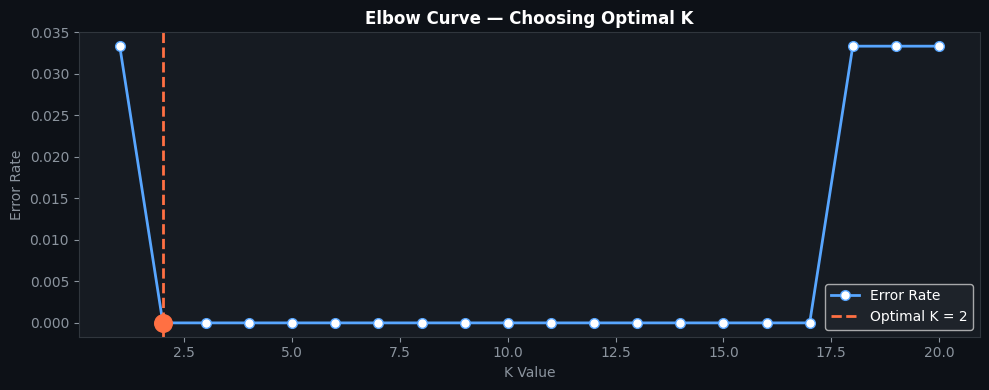

In [8]:
k_range    = range(1, 21)
error_rates = []

for k in k_range:
    knn  = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, pred))

optimal_k = error_rates.index(min(error_rates)) + 1
print(f"Error rates : {[round(e, 3) for e in error_rates]}")
print(f"✅ Optimal K : {optimal_k}")

# Plot elbow curve
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')
ax.plot(list(k_range), error_rates, 'o-', color='#58a6ff', lw=2, ms=7,
        markerfacecolor='white', label='Error Rate')
ax.axvline(x=optimal_k, color='#FF7043', ls='--', lw=2,
           label=f'Optimal K = {optimal_k}')
ax.scatter([optimal_k], [error_rates[optimal_k-1]],
           color='#FF7043', s=160, zorder=5)
ax.set_xlabel('K Value', color='#8b949e')
ax.set_ylabel('Error Rate', color='#8b949e')
ax.set_title('Elbow Curve — Choosing Optimal K', color='white', fontweight='bold')
ax.legend(facecolor='#21262d', labelcolor='white')
ax.tick_params(colors='#8b949e')
for sp in ax.spines.values(): sp.set_edgecolor('#30363d')
plt.tight_layout()
plt.show()


## Step 6 — Train the KNN Model

The three-line scikit-learn workflow from the DecodeLabs blueprint:
```
INSTANTIATE → FIT → PREDICT
```


In [9]:
# INSTANTIATE — Build the frame
model = KNeighborsClassifier(n_neighbors=optimal_k)

# FIT — Memorize the training map
model.fit(X_train, y_train)

print(f"✅ KNN model trained with K = {optimal_k}")
print(f"   Training set size : {X_train.shape[0]} samples")


✅ KNN model trained with K = 2
   Training set size : 120 samples


## Step 7 — Make Predictions on the Test Set

In [10]:
# PREDICT — Apply the learned logic to unseen data
y_pred = model.predict(X_test)

print("First 15 predictions:")
comparison = pd.DataFrame({
    'Actual'   : [iris.target_names[i] for i in y_test[:15]],
    'Predicted': [iris.target_names[i] for i in y_pred[:15]],
    'Correct ✅': [y_test[i] == y_pred[i] for i in range(15)]
})
print(comparison.to_string(index=False))


First 15 predictions:
    Actual  Predicted  Correct ✅
versicolor versicolor       True
    setosa     setosa       True
 virginica  virginica       True
versicolor versicolor       True
versicolor versicolor       True
    setosa     setosa       True
versicolor versicolor       True
 virginica  virginica       True
versicolor versicolor       True
versicolor versicolor       True
 virginica  virginica       True
    setosa     setosa       True
    setosa     setosa       True
    setosa     setosa       True
    setosa     setosa       True


## Step 8 — Evaluate Model Performance

### Why accuracy alone isn't enough
On **imbalanced** datasets, a model predicting only the majority class can score 99% accuracy — the "Accuracy Mirage".  
We use **F1 Score** (harmonic mean of Precision & Recall) for a complete picture.


In [11]:
accuracy   = accuracy_score(y_test, y_pred)
f1_macro   = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
cm         = confusion_matrix(y_test, y_pred)

print("=" * 45)
print(f"  Accuracy              : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  F1 Score (macro)      : {f1_macro:.4f}")
print(f"  F1 Score (weighted)   : {f1_weighted:.4f}")
print("=" * 45)
print()
print("Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


  Accuracy              : 1.0000  (100.00%)
  F1 Score (macro)      : 1.0000
  F1 Score (weighted)   : 1.0000

Full Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Confusion Matrix

Rows = **Actual** class | Columns = **Predicted** class  
Diagonal = correct predictions | Off-diagonal = errors (FP / FN)


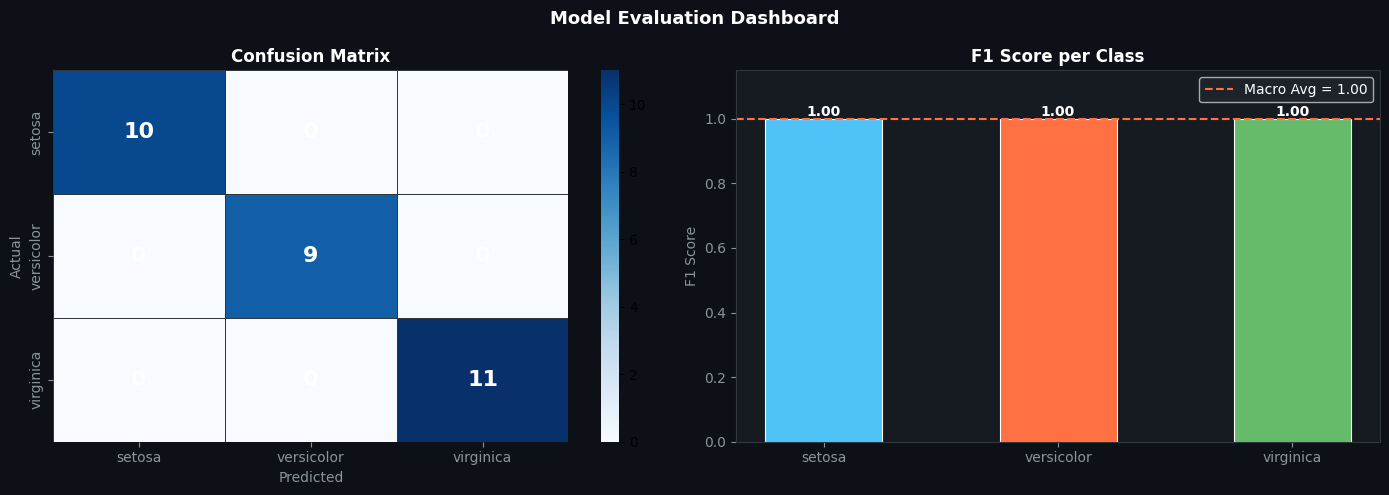

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

# Heatmap
ax = axes[0]
ax.set_facecolor('#161b22')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names,
            ax=ax, linewidths=0.5, linecolor='#30363d',
            annot_kws={'size': 16, 'weight': 'bold', 'color': 'white'})
ax.set_xlabel('Predicted', color='#8b949e')
ax.set_ylabel('Actual',    color='#8b949e')
ax.set_title('Confusion Matrix', color='white', fontweight='bold')
ax.tick_params(colors='#8b949e')

# F1 per class
ax = axes[1]
ax.set_facecolor('#161b22')
f1_per = f1_score(y_test, y_pred, average=None)
bars = ax.bar(iris.target_names, f1_per,
              color=['#4FC3F7', '#FF7043', '#66BB6A'],
              edgecolor='white', lw=0.8, width=0.5)
for bar, score in zip(bars, f1_per):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{score:.2f}', ha='center', color='white', fontweight='bold')
ax.set_ylim(0, 1.15)
ax.axhline(y=f1_macro, color='#FF7043', ls='--',
           label=f'Macro Avg = {f1_macro:.2f}')
ax.set_ylabel('F1 Score', color='#8b949e')
ax.set_title('F1 Score per Class', color='white', fontweight='bold')
ax.legend(facecolor='#21262d', labelcolor='white')
ax.tick_params(colors='#8b949e')
for sp in ax.spines.values(): sp.set_edgecolor('#30363d')

plt.suptitle('Model Evaluation Dashboard', color='white',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 9 — Live Prediction on a New Sample

In [13]:
# Try your own measurements here! ↓
sample = np.array([[5.1, 3.5, 1.4, 0.2]])   # sepal_l, sepal_w, petal_l, petal_w

sample_scaled = scaler.transform(sample)
prediction    = model.predict(sample_scaled)
probabilities = model.predict_proba(sample_scaled)[0]

print("🌸 Live Prediction Demo")
print(f"   Input  : sepal_length={sample[0,0]}, sepal_width={sample[0,1]}, "
      f"petal_length={sample[0,2]}, petal_width={sample[0,3]}")
print(f"   Result : {iris.target_names[prediction[0]].upper()}")
print()
print("   Confidence per class:")
for name, prob in zip(iris.target_names, probabilities):
    bar = '█' * int(prob * 30)
    print(f"   {name:12s} {prob:.2f}  {bar}")


🌸 Live Prediction Demo
   Input  : sepal_length=5.1, sepal_width=3.5, petal_length=1.4, petal_width=0.2
   Result : SETOSA

   Confidence per class:
   setosa       1.00  ██████████████████████████████
   versicolor   0.00  
   virginica    0.00  
